<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Spin_Acoustic_Quantum_Transducer_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## Superconducting Altermagnetic Spin Acoustic Quantum Transducer

This notebook produces heatmaps for a quantum transducer. The model treats a device as three coupled bosonic modes comprising of a superconducting microwave resonator, an altermagnetic spin excitation, and a spin acoustic phonon mode. The classical input output heatmaps function as an accurate fast design scanner for the linear weak drive regime while the QuTiP calculations provide a density matrix verification using Lindblad dissipation, finite Hilbert space truncation, quantum occupations, and single excitation transfer dynamics.

Achieving material specific accuracy requires measured or computed tensors for manganese telluride (MnTe) or ruthenium dioxide ($\text{RuO}_2$), magnetic anisotropy, magnetoelastic constants, acoustic velocity, linewidths, superconducting interface transparency, and crystal domain statistics.

### Working Chain and System Hamiltonian

Here, the energy conversion sequence follows a working chain where a microwave photon ($a$) couples to an altermagnetic spin mode ($s$), which subsequently couples to a spin acoustic phonon ($b$), progressing according to the formal sequence
$$\mathrm{microwave\ photon}\; a \rightarrow \mathrm{altermagnetic\ spin\ mode}\; s \rightarrow \mathrm{spin\ acoustic\ phonon}\; b$$

The rotating frame Hamiltonian ($H$) utilized in the QuTiP cells is established by the equation
$$H/\hbar = \Delta_s s^\dagger s + \Delta_b b^\dagger b + g_{cs}\left(a^\dagger s+a s^\dagger\right) + g_{sm}\left(s^\dagger b+s b^\dagger\right) + \epsilon_d\left(a+a^\dagger\right)$$
where $\hbar$ is the reduced Planck constant, $\Delta_s$ is the detuning of the spin mode, $\Delta_b$ is the detuning of the phonon mode, $s^\dagger$ and $s$ are the creation and annihilation operators for the spin mode, $b^\dagger$ and $b$ are the creation and annihilation operators for the phonon mode, $a^\dagger$ and $a$ are the creation and annihilation operators for the microwave photon mode, $g_{cs}$ is the cavity spin coupling strength, $g_{sm}$ is the spin mechanics coupling strength, and $\epsilon_d$ is the drive amplitude.

This system includes collapse channels represented by the mathematical terms
$$\sqrt{\kappa}\,a, \qquad \sqrt{\gamma_s}\,s, \qquad \sqrt{\gamma_b}\,b$$
where $\kappa$ represents the cavity decay rate, $\gamma_s$ represents the spin mode decay rate, and $\gamma_b$ represents the phonon mode decay rate.

Rates entered as megahertz (MHz) are converted internally to angular units in radians per microsecond ($\text{rad}/\mu\text{s}$) for QuTiP computations because the calculations require strictly angular frequencies. The heatmap axes remain in MHz equivalents since this unit convention represents the usual experimental readout language.

In [1]:
# @title Cell 1: Install and import the scientific stack
"""Install and import libraries for transducer heatmaps and QuTiP checks."""

import importlib.util
import subprocess
import sys


# =============================================================================
# Control knobs
# =============================================================================
USE_UV_PIP = True
INSTALL_PACKAGES = True
PACKAGE_LIST = [
    "numpy",
    "scipy",
    "matplotlib",
    "pandas",
    "qutip",
    "tqdm",
]


def run_command(command: list[str]) -> None:
    """Run a shell command and raise a readable error if it fails."""
    result = subprocess.run(
        command,
        check=False,
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(f"Command failed: {' '.join(command)}")


if INSTALL_PACKAGES:
    if USE_UV_PIP and importlib.util.find_spec("uv") is None:
        run_command([sys.executable, "-m", "pip", "install", "-q", "uv"])

    installer = [sys.executable, "-m"]
    if USE_UV_PIP:
        installer += ["uv", "pip", "install", "--system", "-q"]
    else:
        installer += ["pip", "install", "-q"]
    run_command(installer + PACKAGE_LIST)

import math
from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qutip as qt
from IPython.display import display
from scipy import constants
from tqdm.auto import tqdm

try:
    import cupy as cp
except ImportError:
    cp = None

mpl.rcParams["figure.dpi"] = 250
mpl.rcParams["savefig.dpi"] = 250
mpl.rcParams["figure.figsize"] = (7.5, 4.8)
mpl.rcParams["axes.grid"] = False
mpl.rcParams["font.size"] = 10

print("Scientific stack loaded.")
print(f"QuTiP version: {qt.__version__}")
print(f"CuPy available: {cp is not None}")


Scientific stack loaded.
QuTiP version: 5.3.0
CuPy available: True


In [2]:
# @title Cell 2: Classical coupled-mode model and plotting helpers
"""Model a superconducting altermagnetic spin acoustic transducer."""

# =============================================================================
# Control knobs
# =============================================================================
USE_CUPY_IF_AVAILABLE = True

# Rates are expressed as f = omega / 2 pi equivalents in MHz.
KAPPA_MHZ = 1.20
GAMMA_SPIN_MHZ = 8.00
GAMMA_ACOUSTIC_MHZ = 0.80
KAPPA_EXTERNAL_FRACTION = 0.65
ACOUSTIC_EXTERNAL_FRACTION = 0.55

BASE_MICROWAVE_SPIN_G_MHZ = 6.00
BASE_SPIN_ACOUSTIC_G_MHZ = 10.00

G_SWEEP_MIN_MHZ = 0.05
G_SWEEP_MAX_MHZ = 40.00
G_SWEEP_POINTS = 180

DETUNING_MIN_MHZ = -80.00
DETUNING_MAX_MHZ = 80.00
DETUNING_POINTS = 241

PROBE_MIN_MHZ = -90.00
PROBE_MAX_MHZ = 90.00
PROBE_POINTS = 360

ANGLE_MIN_DEG = 0.00
ANGLE_MAX_DEG = 180.00
ANGLE_POINTS = 181
ALTERMAGNET_HARMONIC = 2
ALTERMAGNET_COUPLING_FLOOR = 0.08
ALTERMAGNET_PHASE_DEG = 0.00

# Spatial geometry knobs in micrometers.
GEOMETRY_LENGTH_UM = 480.00
GEOMETRY_WIDTH_UM = 260.00
GEOMETRY_POINTS_X = 360
GEOMETRY_POINTS_Y = 220
CPW_TRACE_WIDTH_UM = 12.00
CPW_GAP_UM = 6.00
CPW_FIELD_SIGMA_UM = 5.00
CPW_FIELD_DECAY_X_UM = 220.00
ACOUSTIC_WAVELENGTH_UM = 96.00
ACOUSTIC_GUIDE_CENTER_Y_UM = 36.00
ACOUSTIC_GUIDE_SIGMA_Y_UM = 28.00
ALTERMAGNET_LAYER_ATTENUATION = 1.00

EPSILON = 1.0e-12

XP = cp if USE_CUPY_IF_AVAILABLE and cp is not None else np


@dataclass(frozen=True)
class ModeParameters:
    """Container for coupled-mode loss and external coupling parameters."""

    kappa_mhz: float = KAPPA_MHZ
    gamma_spin_mhz: float = GAMMA_SPIN_MHZ
    gamma_acoustic_mhz: float = GAMMA_ACOUSTIC_MHZ
    kappa_external_fraction: float = KAPPA_EXTERNAL_FRACTION
    acoustic_external_fraction: float = ACOUSTIC_EXTERNAL_FRACTION


def to_numpy(array):
    """Convert either a NumPy or CuPy array to NumPy."""
    if cp is not None and isinstance(array, cp.ndarray):
        return cp.asnumpy(array)
    return np.asarray(array)


def altermagnetic_form_factor(
    theta_rad,
    harmonic: int = ALTERMAGNET_HARMONIC,
    floor: float = ALTERMAGNET_COUPLING_FLOOR,
    phase_rad: float = math.radians(ALTERMAGNET_PHASE_DEG),
):
    """Return a symmetry-controlled angular coupling factor."""
    theta_rad = XP.asarray(theta_rad)
    angular_part = XP.abs(XP.cos(harmonic * (theta_rad - phase_rad)))
    return floor + (1.00 - floor) * angular_part


def spin_current_form_factor(
    theta_rad,
    harmonic: int = ALTERMAGNET_HARMONIC,
    phase_rad: float = math.radians(ALTERMAGNET_PHASE_DEG),
):
    """Return a signed symmetry factor for a spin-current proxy."""
    theta_rad = XP.asarray(theta_rad)
    return XP.sin(2.00 * harmonic * (theta_rad - phase_rad))


def build_susceptibility_matrix(
    probe_detuning_mhz,
    spin_detuning_mhz,
    acoustic_detuning_mhz,
    microwave_spin_g_mhz,
    spin_acoustic_g_mhz,
    params: ModeParameters = ModeParameters(),
):
    """Build and invert the three-mode linear response matrix."""
    (
        probe_detuning_mhz,
        spin_detuning_mhz,
        acoustic_detuning_mhz,
        microwave_spin_g_mhz,
        spin_acoustic_g_mhz,
    ) = XP.broadcast_arrays(
        XP.asarray(probe_detuning_mhz),
        XP.asarray(spin_detuning_mhz),
        XP.asarray(acoustic_detuning_mhz),
        XP.asarray(microwave_spin_g_mhz),
        XP.asarray(spin_acoustic_g_mhz),
    )

    shape = probe_detuning_mhz.shape
    matrix = XP.zeros(shape + (3, 3), dtype=XP.complex128)

    cavity_denominator = params.kappa_mhz / 2.00 - 1j * probe_detuning_mhz
    spin_denominator = (
        params.gamma_spin_mhz / 2.00
        - 1j * (probe_detuning_mhz - spin_detuning_mhz)
    )
    acoustic_denominator = (
        params.gamma_acoustic_mhz / 2.00
        - 1j * (probe_detuning_mhz - acoustic_detuning_mhz)
    )

    matrix[..., 0, 0] = cavity_denominator
    matrix[..., 1, 1] = spin_denominator
    matrix[..., 2, 2] = acoustic_denominator
    matrix[..., 0, 1] = 1j * microwave_spin_g_mhz
    matrix[..., 1, 0] = 1j * microwave_spin_g_mhz
    matrix[..., 1, 2] = 1j * spin_acoustic_g_mhz
    matrix[..., 2, 1] = 1j * spin_acoustic_g_mhz

    return XP.linalg.inv(matrix)


def conversion_efficiency(
    probe_detuning_mhz,
    spin_detuning_mhz,
    acoustic_detuning_mhz,
    microwave_spin_g_mhz,
    spin_acoustic_g_mhz,
    params: ModeParameters = ModeParameters(),
):
    """Return microwave input to acoustic output conversion efficiency."""
    susceptibility = build_susceptibility_matrix(
        probe_detuning_mhz=probe_detuning_mhz,
        spin_detuning_mhz=spin_detuning_mhz,
        acoustic_detuning_mhz=acoustic_detuning_mhz,
        microwave_spin_g_mhz=microwave_spin_g_mhz,
        spin_acoustic_g_mhz=spin_acoustic_g_mhz,
        params=params,
    )
    chi_ba = susceptibility[..., 2, 0]
    kappa_external = params.kappa_external_fraction * params.kappa_mhz
    acoustic_external = (
        params.acoustic_external_fraction * params.gamma_acoustic_mhz
    )
    efficiency = kappa_external * acoustic_external * XP.abs(chi_ba) ** 2
    return XP.clip(XP.real(efficiency), 0.00, 1.00)


def microwave_s21(
    probe_detuning_mhz,
    spin_detuning_mhz,
    acoustic_detuning_mhz,
    microwave_spin_g_mhz,
    spin_acoustic_g_mhz,
    params: ModeParameters = ModeParameters(),
):
    """Return an approximate microwave transmission response."""
    susceptibility = build_susceptibility_matrix(
        probe_detuning_mhz=probe_detuning_mhz,
        spin_detuning_mhz=spin_detuning_mhz,
        acoustic_detuning_mhz=acoustic_detuning_mhz,
        microwave_spin_g_mhz=microwave_spin_g_mhz,
        spin_acoustic_g_mhz=spin_acoustic_g_mhz,
        params=params,
    )
    chi_aa = susceptibility[..., 0, 0]
    kappa_external = params.kappa_external_fraction * params.kappa_mhz
    return 1.00 - kappa_external * chi_aa


def bottleneck_cooperativity(
    microwave_spin_g_mhz,
    spin_acoustic_g_mhz,
    params: ModeParameters = ModeParameters(),
):
    """Return a bottleneck cooperativity for the two conversion links."""
    c_mw_spin = (
        4.00 * microwave_spin_g_mhz**2
        / (params.kappa_mhz * params.gamma_spin_mhz)
    )
    c_spin_acoustic = (
        4.00 * spin_acoustic_g_mhz**2
        / (params.gamma_spin_mhz * params.gamma_acoustic_mhz)
    )
    return 1.00 / (
        1.00 / (c_mw_spin + EPSILON)
        + 1.00 / (c_spin_acoustic + EPSILON)
    )


def plot_heatmap(
    data,
    x_values,
    y_values,
    title: str,
    xlabel: str,
    ylabel: str,
    colorbar_label: str,
    log10: bool = False,
    clip_percentile: float | None = None,
):
    """Render a single heatmap as a distinct figure."""
    data_np = to_numpy(data)
    if clip_percentile is not None:
        upper = np.nanpercentile(data_np, clip_percentile)
        data_np = np.clip(data_np, np.nanmin(data_np), upper)

    if log10:
        data_np = np.log10(np.maximum(data_np, EPSILON))

    x_np = to_numpy(x_values)
    y_np = to_numpy(y_values)
    extent = [x_np.min(), x_np.max(), y_np.min(), y_np.max()]

    fig, ax = plt.subplots()
    image = ax.imshow(
        data_np,
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(colorbar_label)
    plt.show()


def build_geometry_fields():
    """Return simple CPW and spin-acoustic spatial mode fields."""
    x_values = XP.linspace(
        -GEOMETRY_LENGTH_UM / 2.00,
        GEOMETRY_LENGTH_UM / 2.00,
        GEOMETRY_POINTS_X,
    )
    y_values = XP.linspace(
        -GEOMETRY_WIDTH_UM / 2.00,
        GEOMETRY_WIDTH_UM / 2.00,
        GEOMETRY_POINTS_Y,
    )
    x_grid, y_grid = XP.meshgrid(x_values, y_values, indexing="xy")

    gap_center = CPW_TRACE_WIDTH_UM / 2.00 + CPW_GAP_UM / 2.00
    left_gap_field = XP.exp(
        -((y_grid + gap_center) ** 2) / (2.00 * CPW_FIELD_SIGMA_UM**2)
    )
    right_gap_field = XP.exp(
        -((y_grid - gap_center) ** 2) / (2.00 * CPW_FIELD_SIGMA_UM**2)
    )
    longitudinal_envelope = XP.exp(
        -(x_grid**2) / (2.00 * CPW_FIELD_DECAY_X_UM**2)
    )
    microwave_field = (left_gap_field + right_gap_field) * longitudinal_envelope

    acoustic_transverse = XP.exp(
        -((y_grid - ACOUSTIC_GUIDE_CENTER_Y_UM) ** 2)
        / (2.00 * ACOUSTIC_GUIDE_SIGMA_Y_UM**2)
    )
    acoustic_longitudinal = XP.sin(
        2.00 * XP.pi * (x_grid + GEOMETRY_LENGTH_UM / 2.00)
        / ACOUSTIC_WAVELENGTH_UM
    )
    strain_field = acoustic_longitudinal * acoustic_transverse

    local_coupling = (
        XP.abs(microwave_field * strain_field) * ALTERMAGNET_LAYER_ATTENUATION
    )

    local_coupling = local_coupling / (XP.max(local_coupling) + EPSILON)
    microwave_field = microwave_field / (XP.max(microwave_field) + EPSILON)
    strain_field = strain_field / (XP.max(XP.abs(strain_field)) + EPSILON)

    return x_values, y_values, microwave_field, strain_field, local_coupling


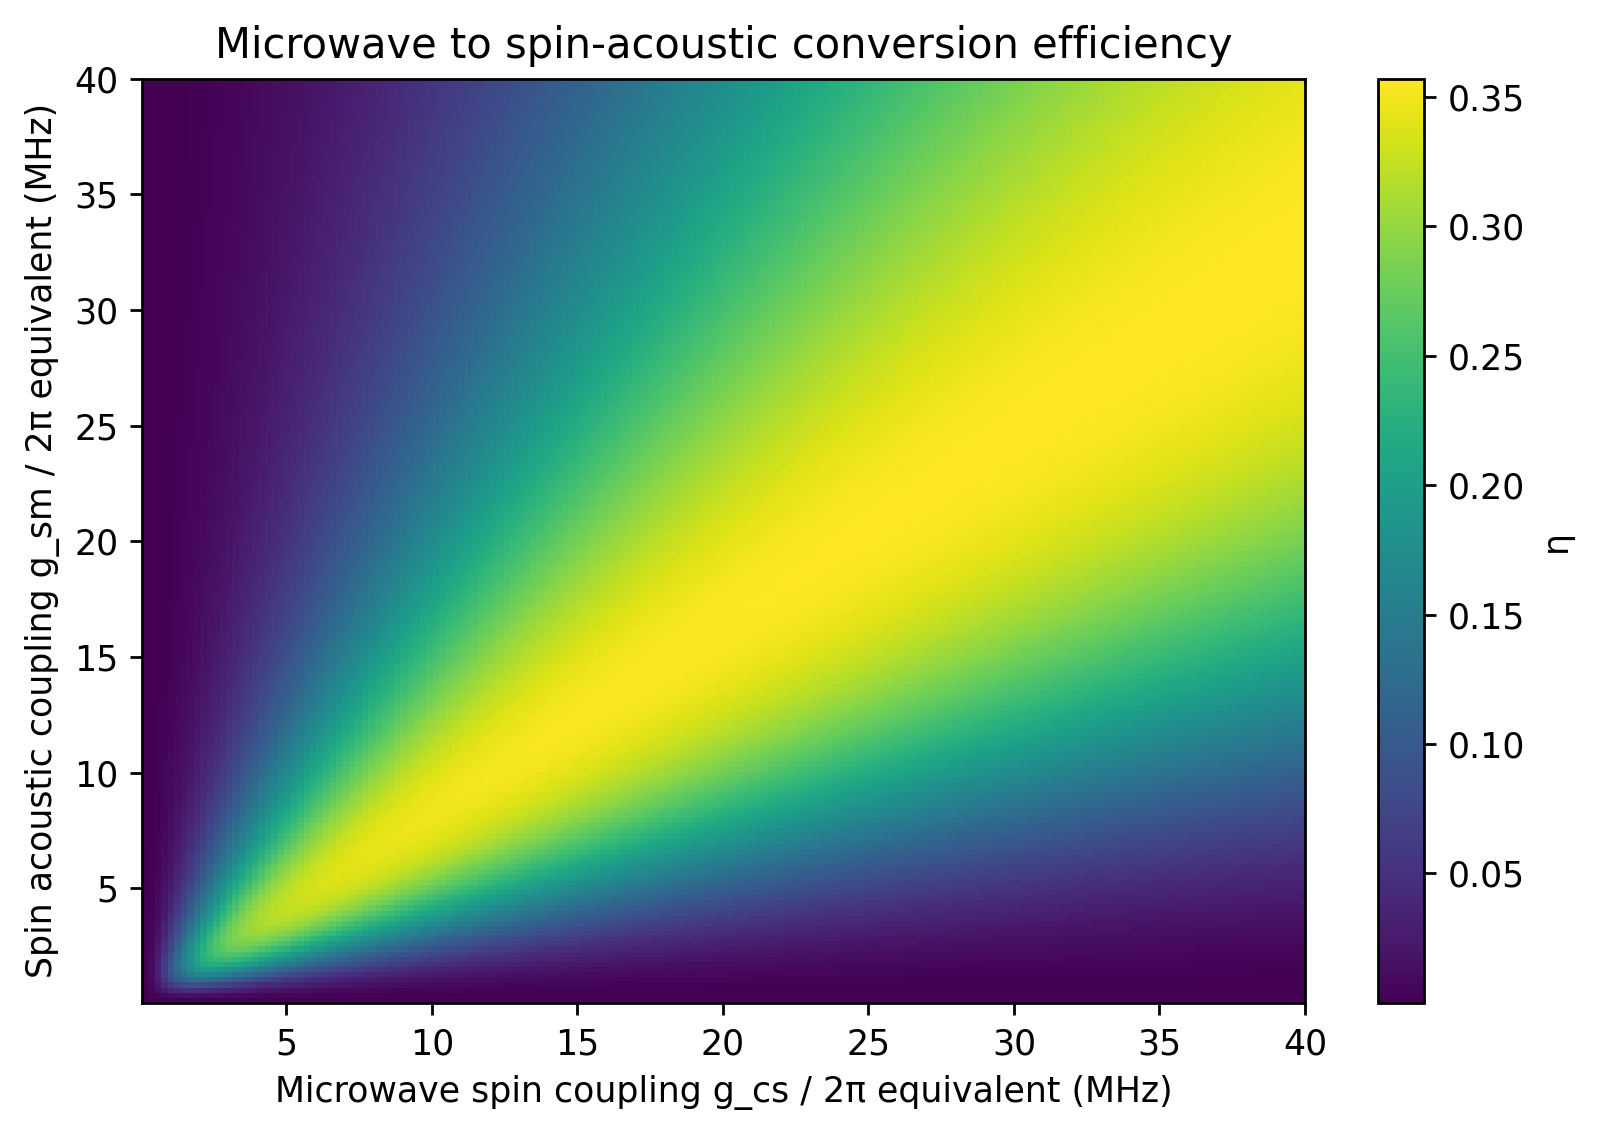

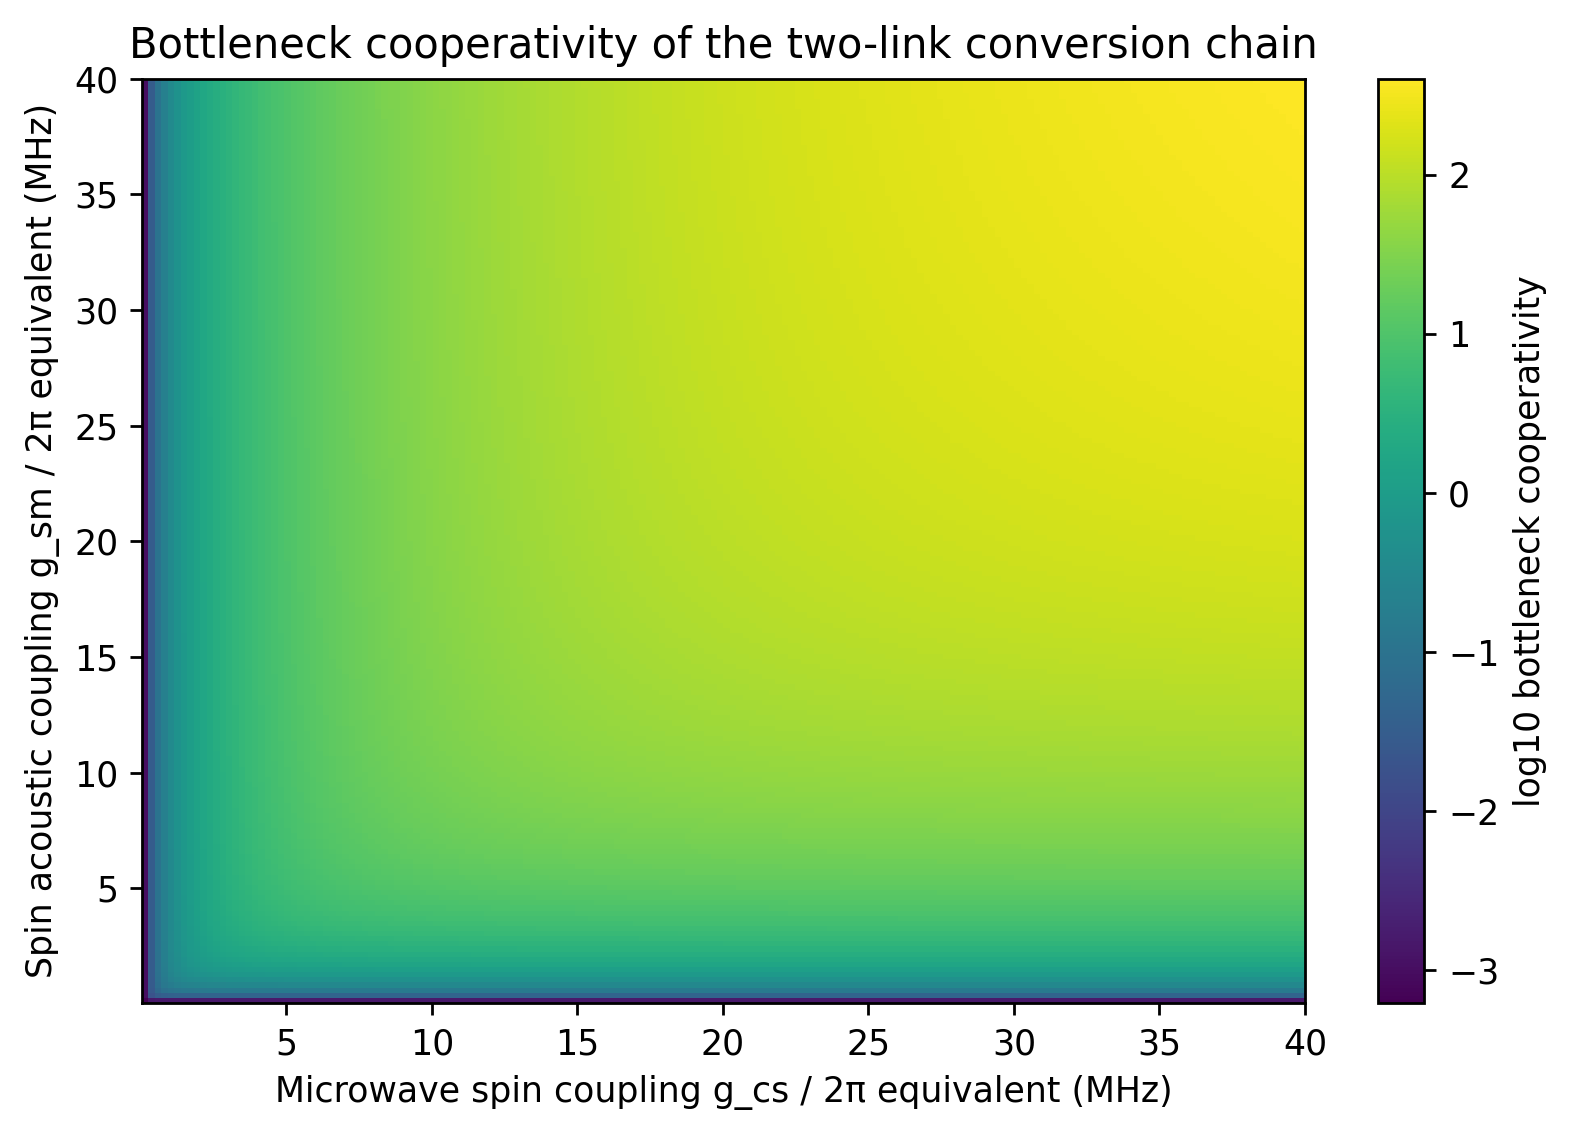

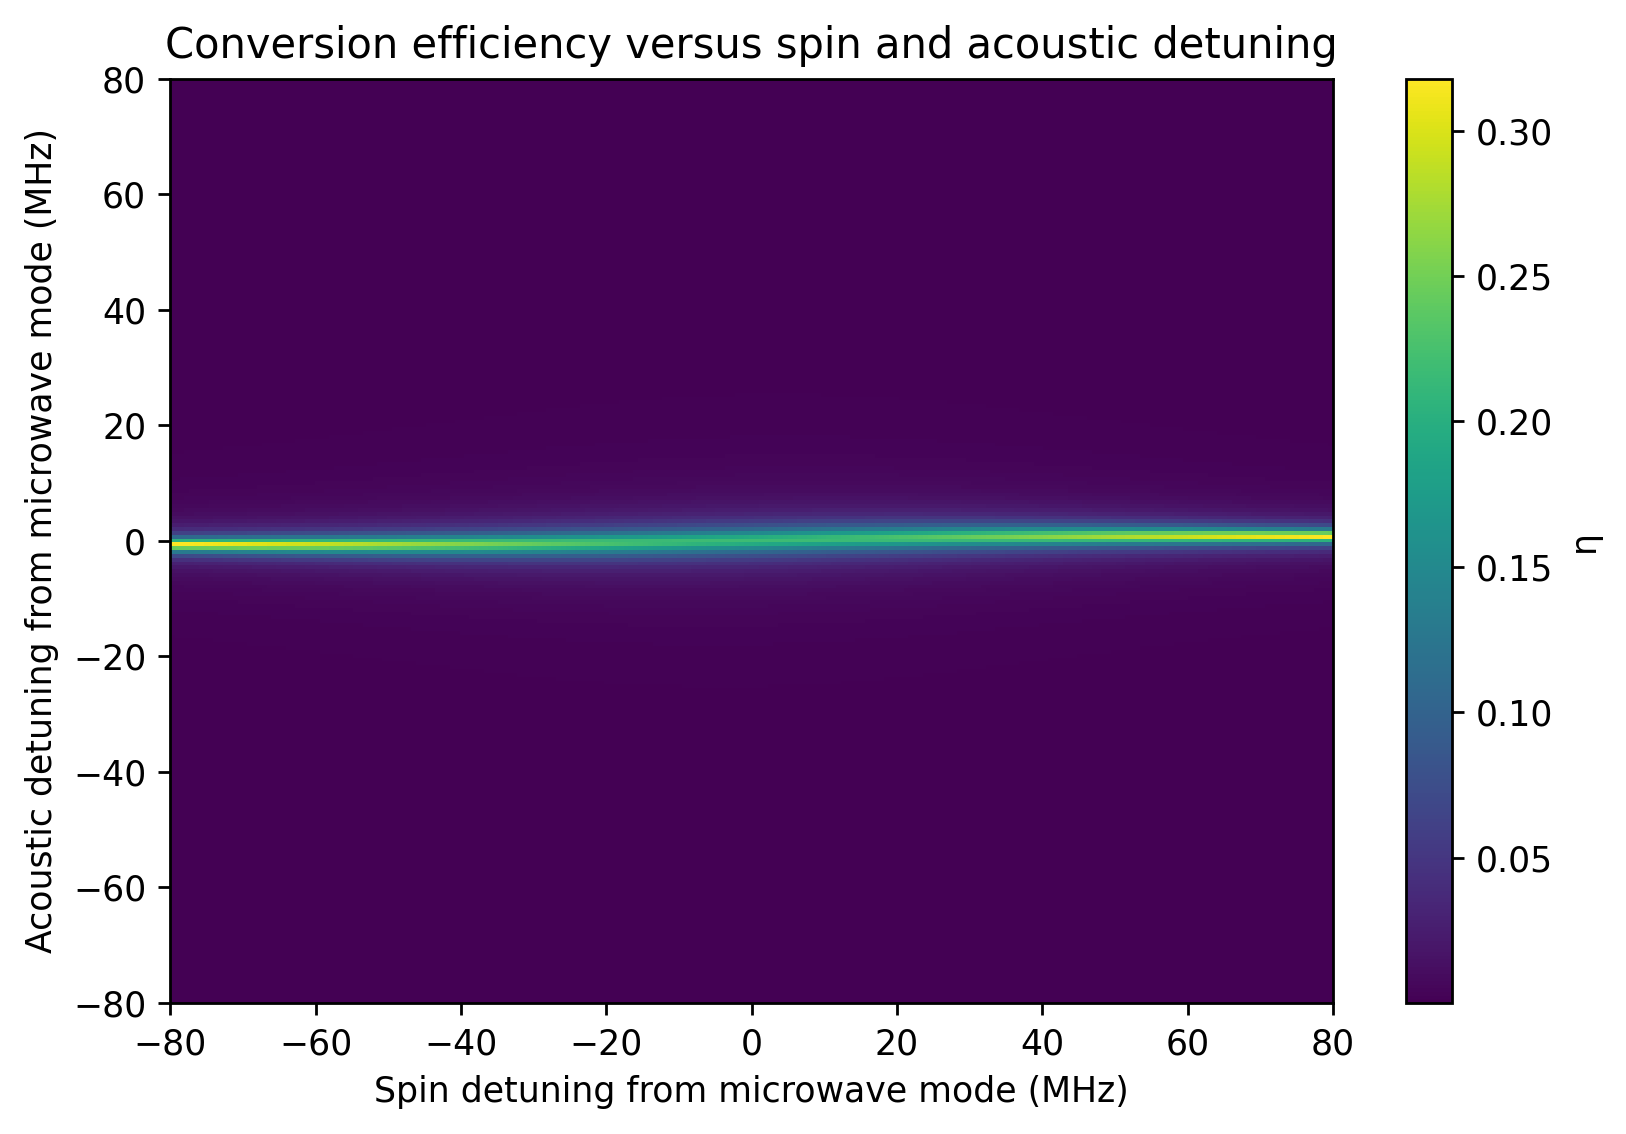

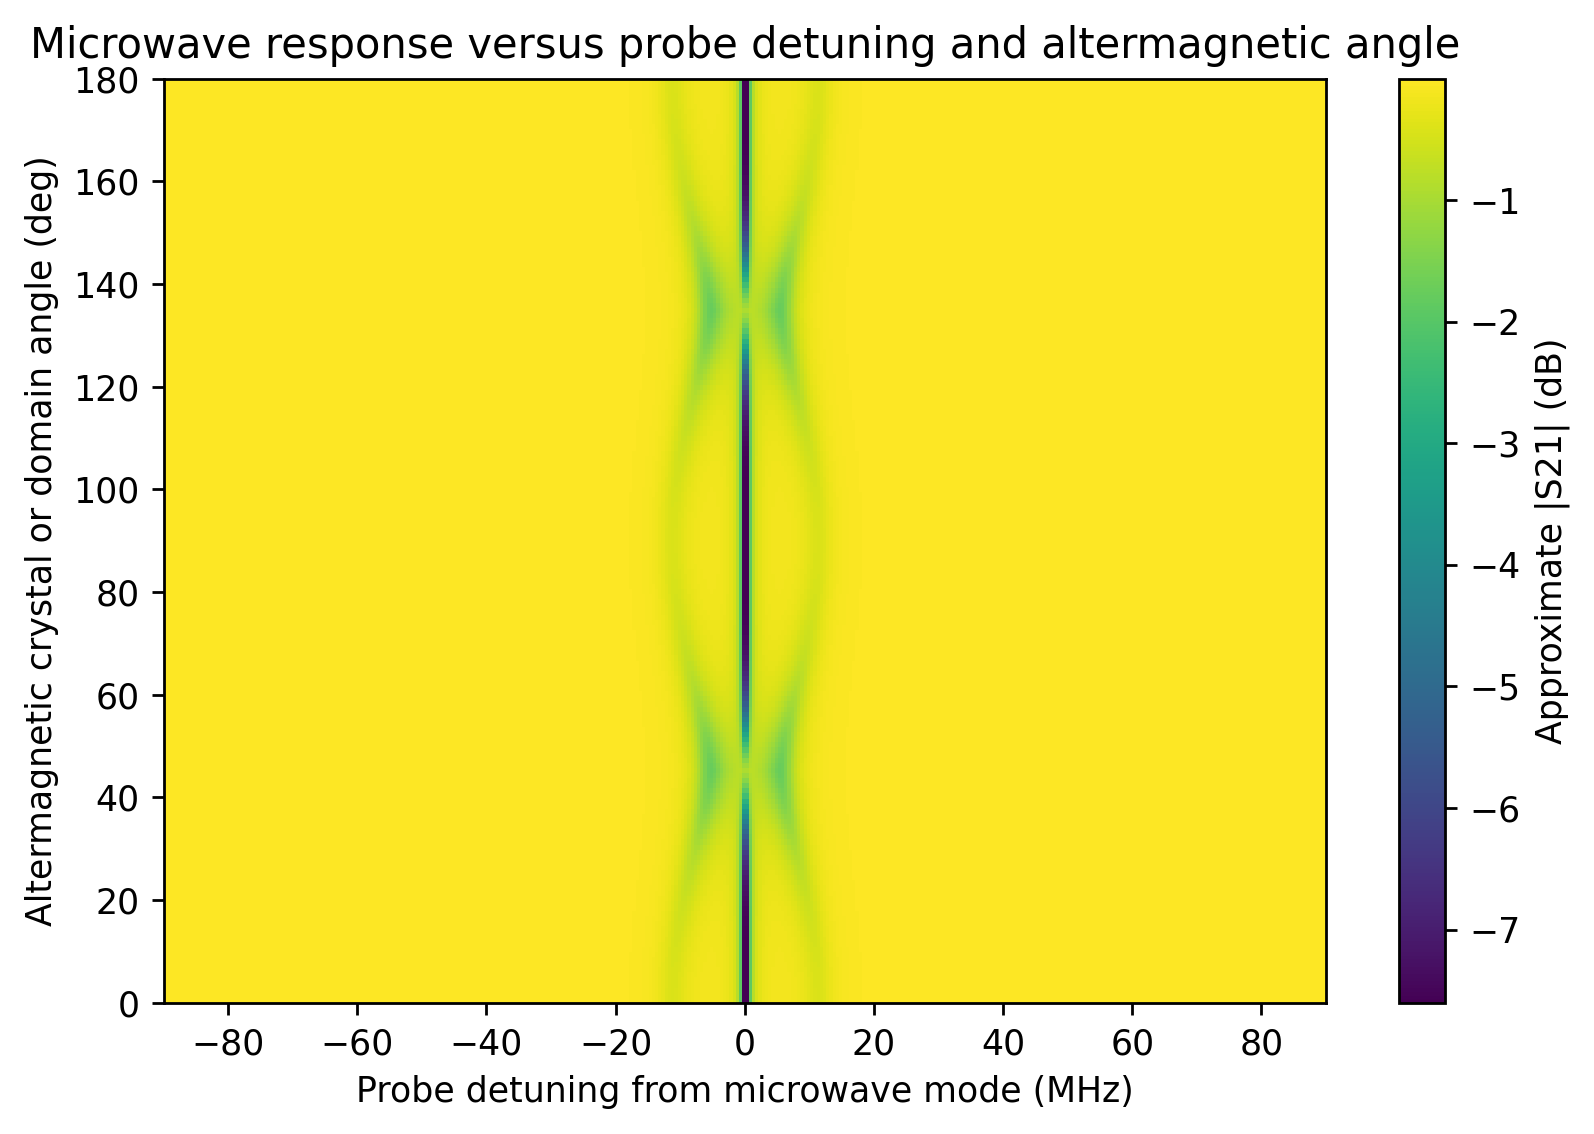

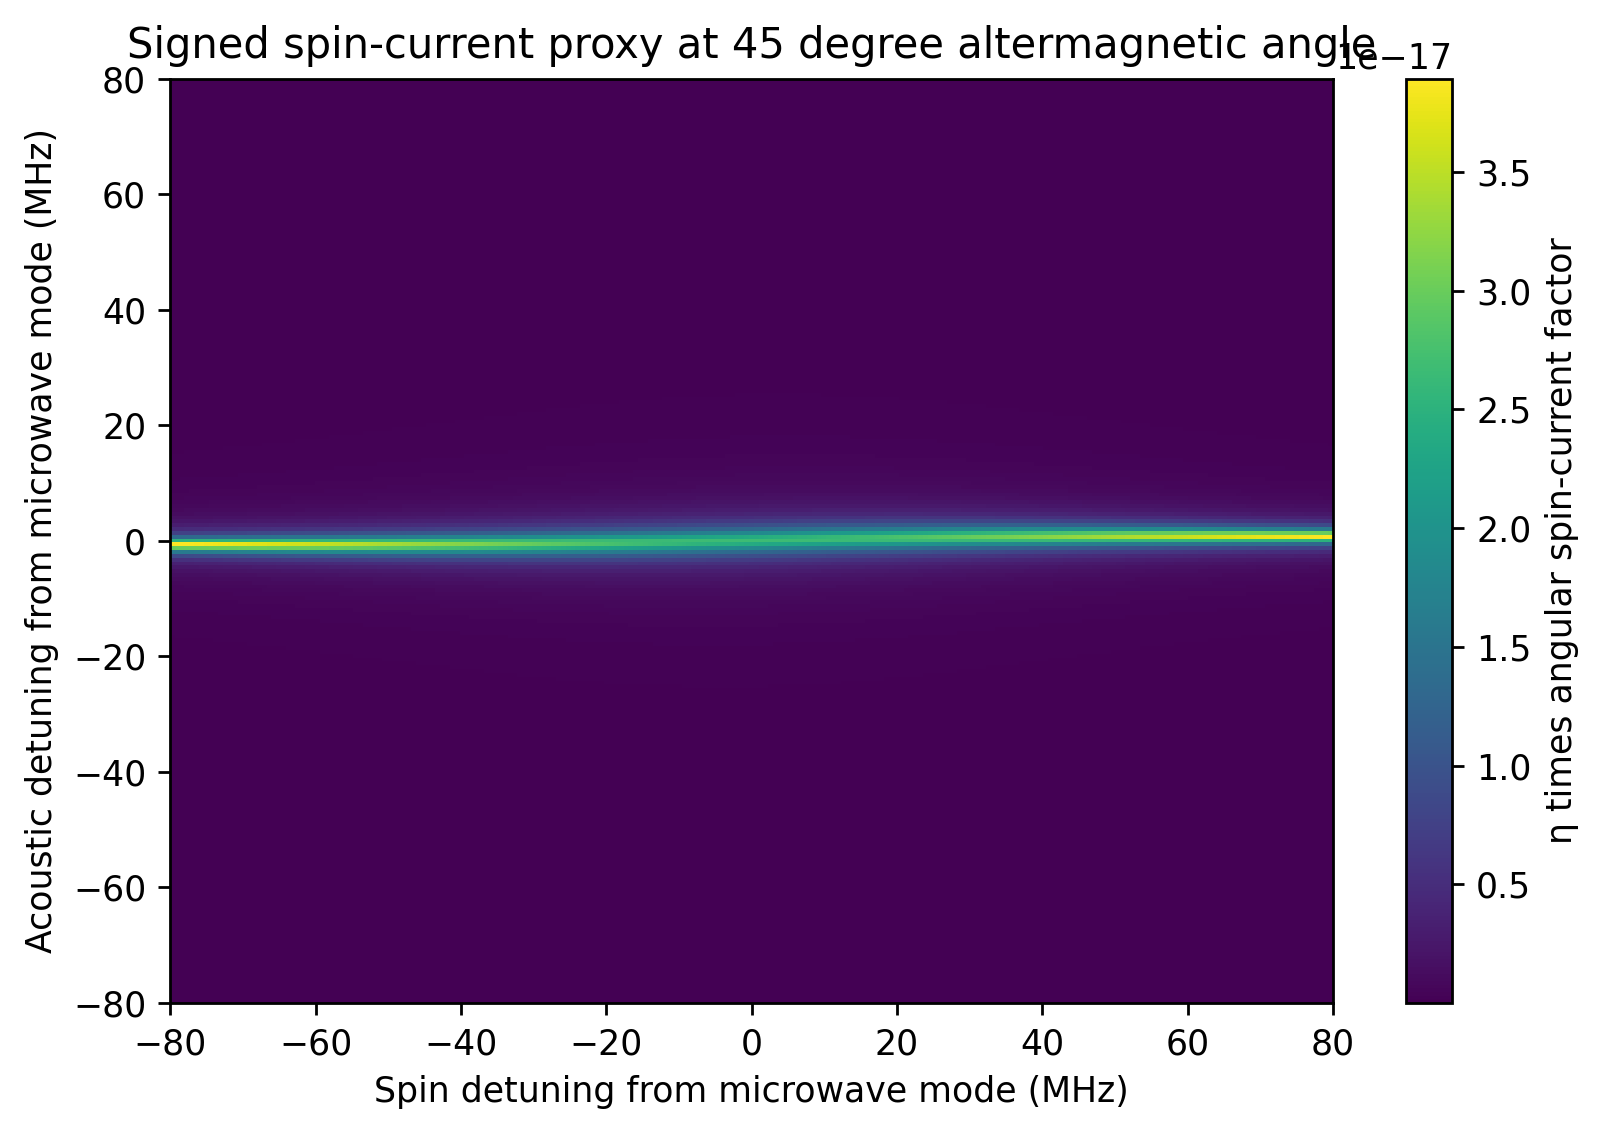

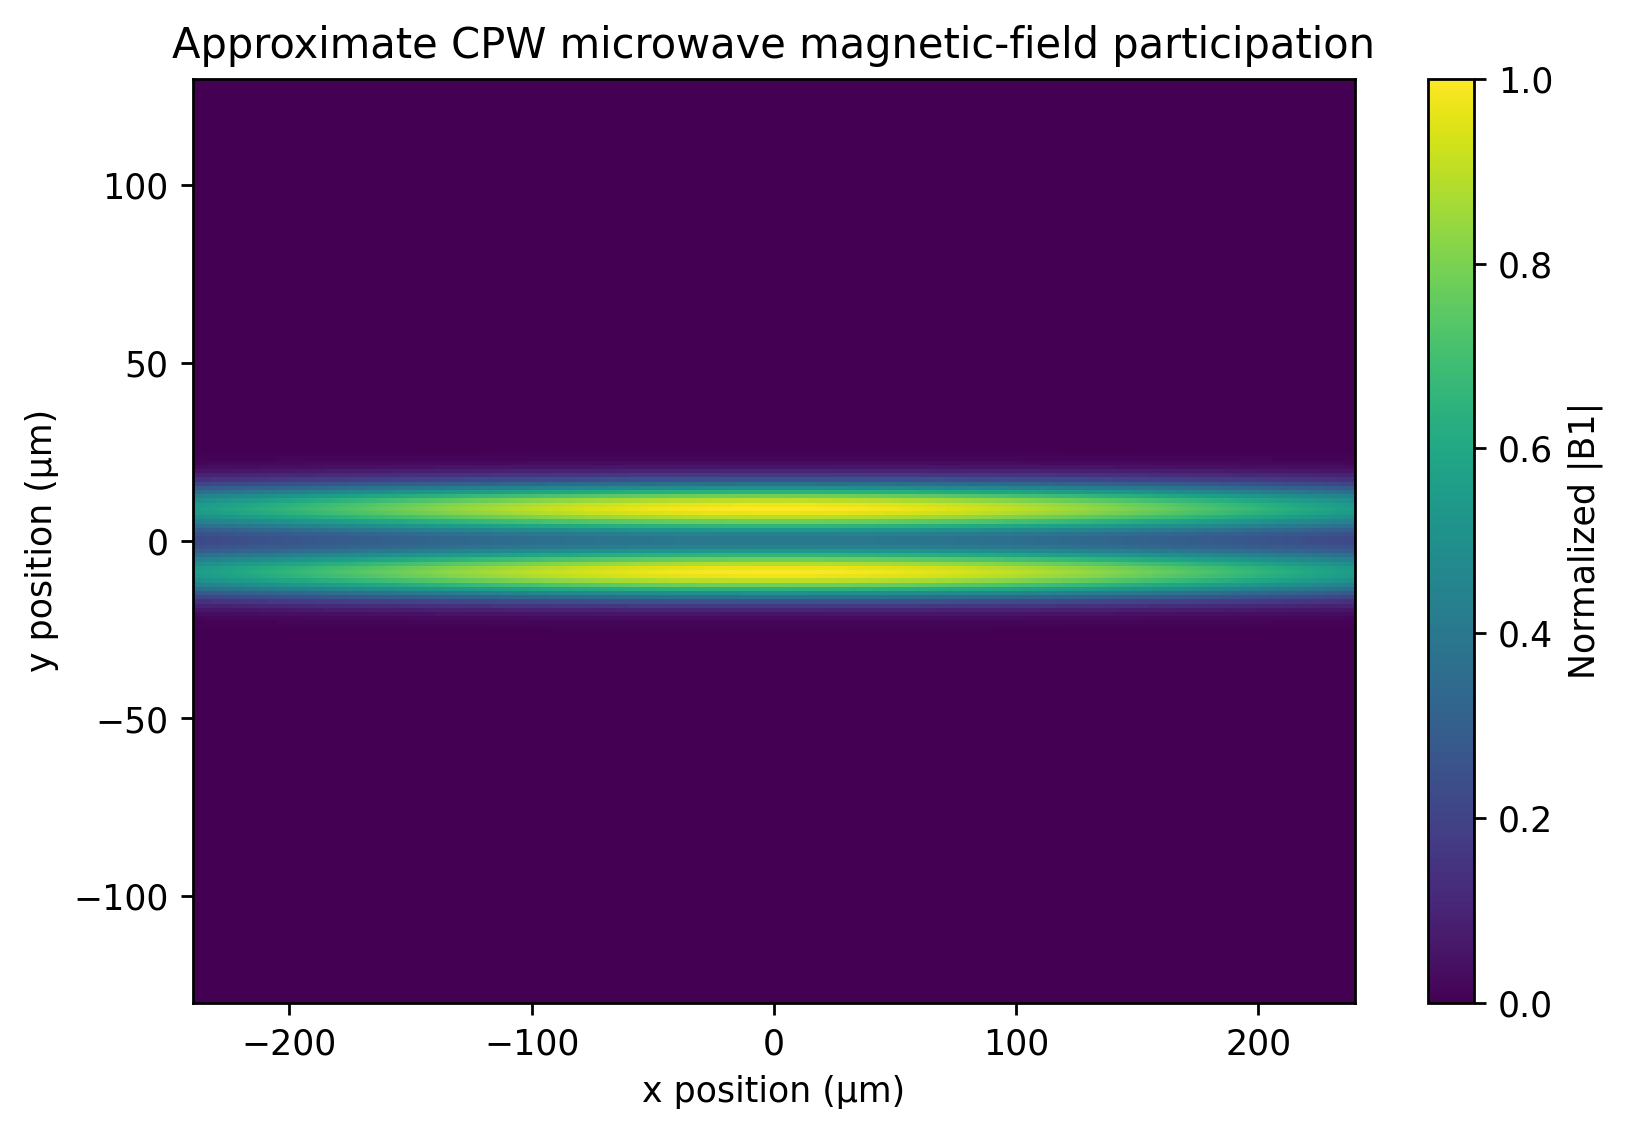

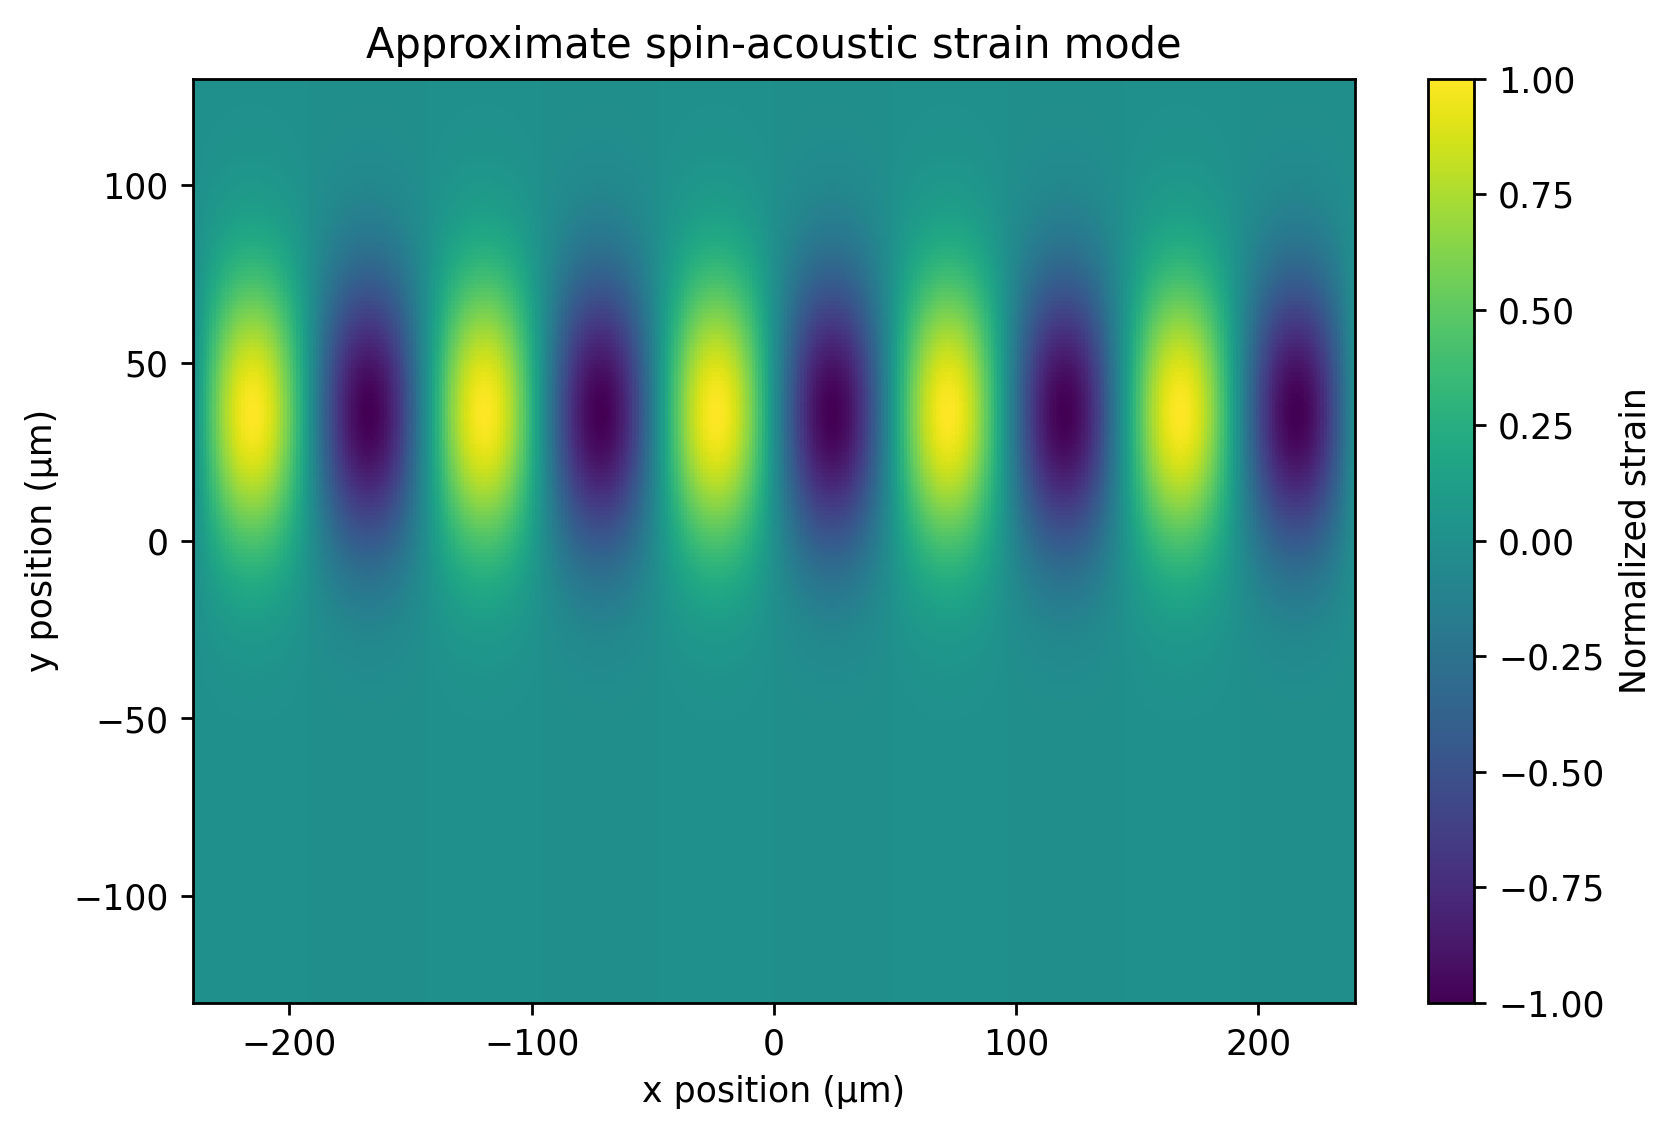

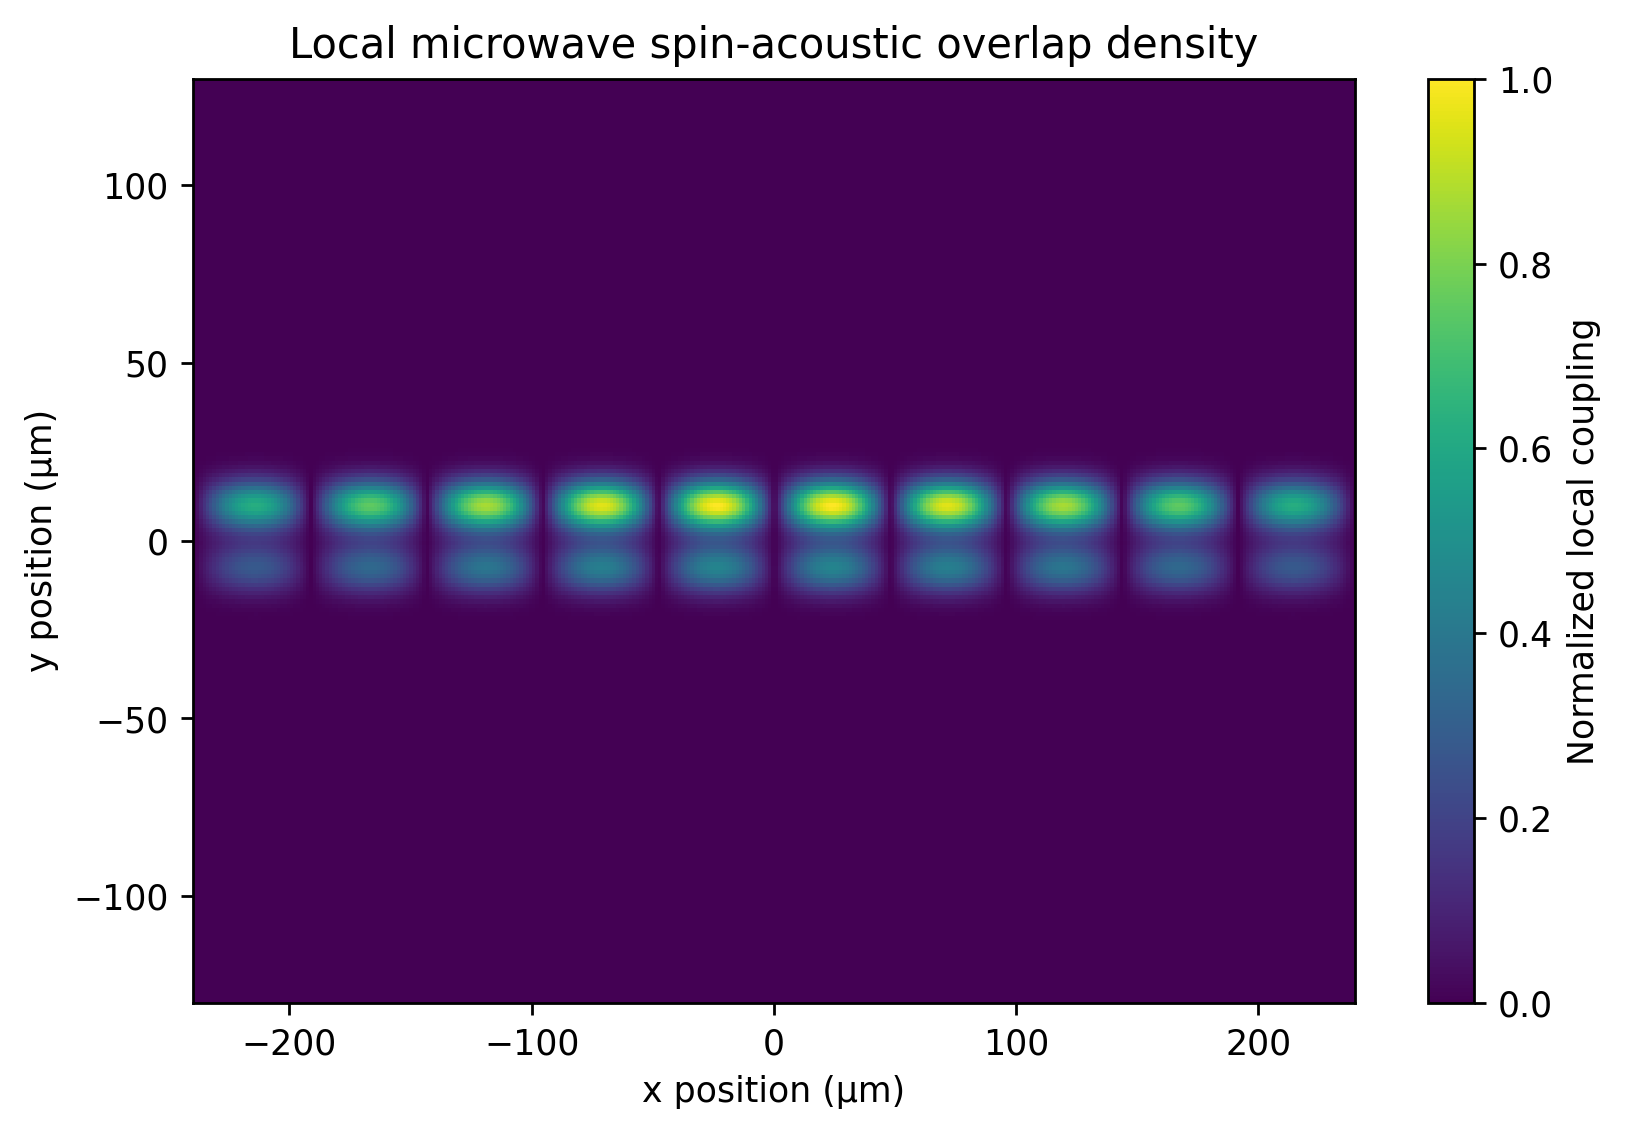

Maximum classical modeled conversion efficiency:
0.3569637353993837
Backend used:
CuPy GPU backend


In [3]:
# @title Cell 3: Preserve the original fast design heatmaps
"""Run classical parameter sweeps and render the original useful heatmaps."""

params = ModeParameters()

# -------------------------------------------------------------------------
# 1. Conversion efficiency versus the two core couplings.
# -------------------------------------------------------------------------
g_values = XP.linspace(G_SWEEP_MIN_MHZ, G_SWEEP_MAX_MHZ, G_SWEEP_POINTS)
g_mw_spin, g_spin_acoustic = XP.meshgrid(g_values, g_values, indexing="xy")

eta_coupling = conversion_efficiency(
    probe_detuning_mhz=0.00,
    spin_detuning_mhz=0.00,
    acoustic_detuning_mhz=0.00,
    microwave_spin_g_mhz=g_mw_spin,
    spin_acoustic_g_mhz=g_spin_acoustic,
    params=params,
)

cooperativity_map = bottleneck_cooperativity(
    microwave_spin_g_mhz=g_mw_spin,
    spin_acoustic_g_mhz=g_spin_acoustic,
    params=params,
)

plot_heatmap(
    data=eta_coupling,
    x_values=g_values,
    y_values=g_values,
    title="Microwave to spin-acoustic conversion efficiency",
    xlabel="Microwave spin coupling g_cs / 2π equivalent (MHz)",
    ylabel="Spin acoustic coupling g_sm / 2π equivalent (MHz)",
    colorbar_label="η",
    log10=False,
)

plot_heatmap(
    data=cooperativity_map,
    x_values=g_values,
    y_values=g_values,
    title="Bottleneck cooperativity of the two-link conversion chain",
    xlabel="Microwave spin coupling g_cs / 2π equivalent (MHz)",
    ylabel="Spin acoustic coupling g_sm / 2π equivalent (MHz)",
    colorbar_label="log10 bottleneck cooperativity",
    log10=True,
)

# -------------------------------------------------------------------------
# 2. Detuning tolerance heatmap.
# -------------------------------------------------------------------------
detuning_values = XP.linspace(
    DETUNING_MIN_MHZ,
    DETUNING_MAX_MHZ,
    DETUNING_POINTS,
)
spin_detuning, acoustic_detuning = XP.meshgrid(
    detuning_values,
    detuning_values,
    indexing="xy",
)

eta_detuning = conversion_efficiency(
    probe_detuning_mhz=0.00,
    spin_detuning_mhz=spin_detuning,
    acoustic_detuning_mhz=acoustic_detuning,
    microwave_spin_g_mhz=BASE_MICROWAVE_SPIN_G_MHZ,
    spin_acoustic_g_mhz=BASE_SPIN_ACOUSTIC_G_MHZ,
    params=params,
)

plot_heatmap(
    data=eta_detuning,
    x_values=detuning_values,
    y_values=detuning_values,
    title="Conversion efficiency versus spin and acoustic detuning",
    xlabel="Spin detuning from microwave mode (MHz)",
    ylabel="Acoustic detuning from microwave mode (MHz)",
    colorbar_label="η",
    log10=False,
)

# -------------------------------------------------------------------------
# 3. Altermagnetic crystal orientation heatmap.
# -------------------------------------------------------------------------
angle_values_deg = XP.linspace(ANGLE_MIN_DEG, ANGLE_MAX_DEG, ANGLE_POINTS)
probe_values = XP.linspace(PROBE_MIN_MHZ, PROBE_MAX_MHZ, PROBE_POINTS)

angle_grid_deg, probe_grid = XP.meshgrid(
    angle_values_deg,
    probe_values,
    indexing="ij",
)
angle_grid_rad = XP.deg2rad(angle_grid_deg)

orientation_factor = altermagnetic_form_factor(angle_grid_rad)
orientation_spin_acoustic_g = BASE_SPIN_ACOUSTIC_G_MHZ * orientation_factor

s21_orientation = microwave_s21(
    probe_detuning_mhz=probe_grid,
    spin_detuning_mhz=0.00,
    acoustic_detuning_mhz=0.00,
    microwave_spin_g_mhz=BASE_MICROWAVE_SPIN_G_MHZ,
    spin_acoustic_g_mhz=orientation_spin_acoustic_g,
    params=params,
)

s21_db = 20.00 * XP.log10(XP.abs(s21_orientation) + EPSILON)

plot_heatmap(
    data=s21_db,
    x_values=probe_values,
    y_values=angle_values_deg,
    title="Microwave response versus probe detuning and altermagnetic angle",
    xlabel="Probe detuning from microwave mode (MHz)",
    ylabel="Altermagnetic crystal or domain angle (deg)",
    colorbar_label="Approximate |S21| (dB)",
    log10=False,
)

signed_spin_current_proxy = eta_detuning * spin_current_form_factor(
    XP.deg2rad(45.00)
)

plot_heatmap(
    data=signed_spin_current_proxy,
    x_values=detuning_values,
    y_values=detuning_values,
    title="Signed spin-current proxy at 45 degree altermagnetic angle",
    xlabel="Spin detuning from microwave mode (MHz)",
    ylabel="Acoustic detuning from microwave mode (MHz)",
    colorbar_label="η times angular spin-current factor",
    log10=False,
)

# -------------------------------------------------------------------------
# 4. Spatial geometry overlap heatmaps.
# -------------------------------------------------------------------------
(
    x_values_um,
    y_values_um,
    microwave_field,
    strain_field,
    local_coupling,
) = build_geometry_fields()

plot_heatmap(
    data=microwave_field,
    x_values=x_values_um,
    y_values=y_values_um,
    title="Approximate CPW microwave magnetic-field participation",
    xlabel="x position (µm)",
    ylabel="y position (µm)",
    colorbar_label="Normalized |B1|",
    log10=False,
)

plot_heatmap(
    data=strain_field,
    x_values=x_values_um,
    y_values=y_values_um,
    title="Approximate spin-acoustic strain mode",
    xlabel="x position (µm)",
    ylabel="y position (µm)",
    colorbar_label="Normalized strain",
    log10=False,
)

plot_heatmap(
    data=local_coupling,
    x_values=x_values_um,
    y_values=y_values_um,
    title="Local microwave spin-acoustic overlap density",
    xlabel="x position (µm)",
    ylabel="y position (µm)",
    colorbar_label="Normalized local coupling",
    log10=False,
)

print("Maximum classical modeled conversion efficiency:")
print(float(to_numpy(XP.max(eta_coupling))))

print("Backend used:")
print("CuPy GPU backend" if XP.__name__ == "cupy" else "NumPy CPU backend")


In [4]:
# @title Cell 4: QuTiP open-system model for the three-mode chain
"""Build QuTiP operators and numerical solvers for the transducer model."""

# =============================================================================
# Control knobs
# =============================================================================
QUTIP_CUTOFF = 3
QUTIP_SINGLE_EXCITATION_CUTOFF = 2
QUTIP_DRIVE_EPSILON_MHZ = 0.035
QUTIP_STEADY_DETUNING_MIN_MHZ = -45.00
QUTIP_STEADY_DETUNING_MAX_MHZ = 45.00
QUTIP_STEADY_DETUNING_POINTS = 31

RUN_QUTIP_STEADY_STATE_MAP = True
RUN_QUTIP_TIME_TRANSFER_MAP = True

QUTIP_TRANSFER_G_MIN_MHZ = 0.20
QUTIP_TRANSFER_G_MAX_MHZ = 24.00
QUTIP_TRANSFER_G_POINTS = 17
QUTIP_TRANSFER_TIME_US = 2.00
QUTIP_TRANSFER_TIME_POINTS = 160

ANGULAR = 2.00 * np.pi
QUTIP_SOLVER_OPTIONS = {
    "progress_bar": "",
    "store_states": False,
    "normalize_output": True,
    "nsteps": 20_000,
}


@dataclass(frozen=True)
class QutipOperators:
    """Container for tensor-product mode operators."""

    a: qt.Qobj
    s: qt.Qobj
    b: qt.Qobj
    n_a: qt.Qobj
    n_s: qt.Qobj
    n_b: qt.Qobj


def mhz_to_rad_per_us(value_mhz: float | np.ndarray) -> float | np.ndarray:
    """Convert a MHz-equivalent rate into angular rad/µs units."""
    return ANGULAR * value_mhz


def make_operators(cutoff: int) -> QutipOperators:
    """Construct tensor-product mode operators for three bosonic modes."""
    eye = qt.qeye(cutoff)
    destroy = qt.destroy(cutoff)
    a = qt.tensor(destroy, eye, eye)
    s = qt.tensor(eye, destroy, eye)
    b = qt.tensor(eye, eye, destroy)
    return QutipOperators(
        a=a,
        s=s,
        b=b,
        n_a=a.dag() * a,
        n_s=s.dag() * s,
        n_b=b.dag() * b,
    )


def build_qutip_hamiltonian(
    ops: QutipOperators,
    spin_detuning_mhz: float,
    acoustic_detuning_mhz: float,
    microwave_spin_g_mhz: float,
    spin_acoustic_g_mhz: float,
    drive_epsilon_mhz: float = 0.00,
) -> qt.Qobj:
    """Return the rotating-frame three-mode Hamiltonian in rad/µs."""
    hamiltonian = (
        mhz_to_rad_per_us(spin_detuning_mhz) * ops.n_s
        + mhz_to_rad_per_us(acoustic_detuning_mhz) * ops.n_b
        + mhz_to_rad_per_us(microwave_spin_g_mhz)
        * (ops.a.dag() * ops.s + ops.a * ops.s.dag())
        + mhz_to_rad_per_us(spin_acoustic_g_mhz)
        * (ops.s.dag() * ops.b + ops.s * ops.b.dag())
        + mhz_to_rad_per_us(drive_epsilon_mhz) * (ops.a + ops.a.dag())
    )
    return hamiltonian


def build_collapse_operators(
    ops: QutipOperators,
    params: ModeParameters = ModeParameters(),
) -> list[qt.Qobj]:
    """Return Lindblad collapse operators in sqrt(rad/µs) units."""
    return [
        math.sqrt(mhz_to_rad_per_us(params.kappa_mhz)) * ops.a,
        math.sqrt(mhz_to_rad_per_us(params.gamma_spin_mhz)) * ops.s,
        math.sqrt(mhz_to_rad_per_us(params.gamma_acoustic_mhz)) * ops.b,
    ]


def qutip_steady_observables(
    spin_detuning_mhz: float,
    acoustic_detuning_mhz: float,
    microwave_spin_g_mhz: float = BASE_MICROWAVE_SPIN_G_MHZ,
    spin_acoustic_g_mhz: float = BASE_SPIN_ACOUSTIC_G_MHZ,
    drive_epsilon_mhz: float = QUTIP_DRIVE_EPSILON_MHZ,
    cutoff: int = QUTIP_CUTOFF,
    params: ModeParameters = ModeParameters(),
) -> dict[str, float]:
    """Compute steady-state occupations and acoustic output flux proxy."""
    ops = make_operators(cutoff)
    hamiltonian = build_qutip_hamiltonian(
        ops=ops,
        spin_detuning_mhz=spin_detuning_mhz,
        acoustic_detuning_mhz=acoustic_detuning_mhz,
        microwave_spin_g_mhz=microwave_spin_g_mhz,
        spin_acoustic_g_mhz=spin_acoustic_g_mhz,
        drive_epsilon_mhz=drive_epsilon_mhz,
    )
    collapse_operators = build_collapse_operators(ops, params=params)
    rho_ss = qt.steadystate(hamiltonian, c_ops=collapse_operators)

    n_a = float(np.real(qt.expect(ops.n_a, rho_ss)))
    n_s = float(np.real(qt.expect(ops.n_s, rho_ss)))
    n_b = float(np.real(qt.expect(ops.n_b, rho_ss)))
    acoustic_output_flux = (
        mhz_to_rad_per_us(
            params.acoustic_external_fraction * params.gamma_acoustic_mhz
        )
        * n_b
    )

    return {
        "n_microwave": n_a,
        "n_spin": n_s,
        "n_acoustic": n_b,
        "acoustic_output_flux_rad_per_us": float(acoustic_output_flux),
    }


def qutip_max_single_phonon_transfer(
    microwave_spin_g_mhz: float,
    spin_acoustic_g_mhz: float,
    spin_detuning_mhz: float = 0.00,
    acoustic_detuning_mhz: float = 0.00,
    cutoff: int = QUTIP_SINGLE_EXCITATION_CUTOFF,
    params: ModeParameters = ModeParameters(),
) -> float:
    """Return maximum phonon occupation from an initial microwave photon."""
    ops = make_operators(cutoff)
    hamiltonian = build_qutip_hamiltonian(
        ops=ops,
        spin_detuning_mhz=spin_detuning_mhz,
        acoustic_detuning_mhz=acoustic_detuning_mhz,
        microwave_spin_g_mhz=microwave_spin_g_mhz,
        spin_acoustic_g_mhz=spin_acoustic_g_mhz,
        drive_epsilon_mhz=0.00,
    )
    collapse_operators = build_collapse_operators(ops, params=params)
    initial_state = qt.tensor(
        qt.basis(cutoff, 1),
        qt.basis(cutoff, 0),
        qt.basis(cutoff, 0),
    )
    time_values = np.linspace(
        0.00,
        QUTIP_TRANSFER_TIME_US,
        QUTIP_TRANSFER_TIME_POINTS,
    )

    # Keyword arguments are used here for QuTiP 5 compatibility. Some recent
    # QuTiP builds allow only H, rho0, and tlist as positional arguments.
    result = qt.mesolve(
        H=hamiltonian,
        rho0=initial_state,
        tlist=time_values,
        c_ops=collapse_operators,
        e_ops=[ops.n_b],
        options=QUTIP_SOLVER_OPTIONS,
    )
    return float(np.max(np.real(result.expect[0])))


print("QuTiP operators and solvers are ready.")


QuTiP operators and solvers are ready.


In [ ]:
# @title Cell 5: QuTiP heatmaps and quantum-noise design maps
"""Render QuTiP validation heatmaps and thermal-noise design constraints."""

# -------------------------------------------------------------------------
# 1. QuTiP steady-state phonon output versus detuning.
# -------------------------------------------------------------------------
if RUN_QUTIP_STEADY_STATE_MAP:
    qutip_detuning_values = np.linspace(
        QUTIP_STEADY_DETUNING_MIN_MHZ,
        QUTIP_STEADY_DETUNING_MAX_MHZ,
        QUTIP_STEADY_DETUNING_POINTS,
    )
    qutip_phonon_map = np.zeros(
        (QUTIP_STEADY_DETUNING_POINTS, QUTIP_STEADY_DETUNING_POINTS)
    )
    qutip_spin_map = np.zeros_like(qutip_phonon_map)
    qutip_flux_map = np.zeros_like(qutip_phonon_map)

    iterator = tqdm(
        enumerate(qutip_detuning_values),
        total=QUTIP_STEADY_DETUNING_POINTS,
        desc="QuTiP steady-state rows",
    )
    for row_index, acoustic_detuning_mhz in iterator:
        for col_index, spin_detuning_mhz in enumerate(qutip_detuning_values):
            observables = qutip_steady_observables(
                spin_detuning_mhz=spin_detuning_mhz,
                acoustic_detuning_mhz=acoustic_detuning_mhz,
            )
            qutip_phonon_map[row_index, col_index] = observables["n_acoustic"]
            qutip_spin_map[row_index, col_index] = observables["n_spin"]
            qutip_flux_map[row_index, col_index] = observables[
                "acoustic_output_flux_rad_per_us"
            ]

    qutip_phonon_map_normalized = qutip_phonon_map / (
        np.max(qutip_phonon_map) + EPSILON
    )
    qutip_flux_map_normalized = qutip_flux_map / (np.max(qutip_flux_map) + EPSILON)

    plot_heatmap(
        data=qutip_phonon_map_normalized,
        x_values=qutip_detuning_values,
        y_values=qutip_detuning_values,
        title="QuTiP normalized steady-state acoustic occupation",
        xlabel="Spin detuning from microwave mode (MHz)",
        ylabel="Acoustic detuning from microwave mode (MHz)",
        colorbar_label="Normalized ⟨b†b⟩",
        log10=False,
    )

    plot_heatmap(
        data=qutip_flux_map_normalized,
        x_values=qutip_detuning_values,
        y_values=qutip_detuning_values,
        title="QuTiP normalized acoustic output flux proxy",
        xlabel="Spin detuning from microwave mode (MHz)",
        ylabel="Acoustic detuning from microwave mode (MHz)",
        colorbar_label="Normalized external phonon flux",
        log10=False,
    )

    classical_eta_subset = conversion_efficiency(
        probe_detuning_mhz=0.00,
        spin_detuning_mhz=qutip_detuning_values[None, :],
        acoustic_detuning_mhz=qutip_detuning_values[:, None],
        microwave_spin_g_mhz=BASE_MICROWAVE_SPIN_G_MHZ,
        spin_acoustic_g_mhz=BASE_SPIN_ACOUSTIC_G_MHZ,
        params=params,
    )
    classical_eta_subset = to_numpy(classical_eta_subset)
    classical_eta_subset /= np.max(classical_eta_subset) + EPSILON
    residual_map = np.abs(classical_eta_subset - qutip_flux_map_normalized)

    plot_heatmap(
        data=residual_map,
        x_values=qutip_detuning_values,
        y_values=qutip_detuning_values,
        title="Classical linear-response versus QuTiP residual",
        xlabel="Spin detuning from microwave mode (MHz)",
        ylabel="Acoustic detuning from microwave mode (MHz)",
        colorbar_label="Absolute normalized residual",
        log10=False,
    )

# -------------------------------------------------------------------------
# 2. QuTiP transient single-excitation transfer versus two couplings.
# -------------------------------------------------------------------------
if RUN_QUTIP_TIME_TRANSFER_MAP:
    qutip_transfer_g_values = np.linspace(
        QUTIP_TRANSFER_G_MIN_MHZ,
        QUTIP_TRANSFER_G_MAX_MHZ,
        QUTIP_TRANSFER_G_POINTS,
    )
    transfer_map = np.zeros(
        (QUTIP_TRANSFER_G_POINTS, QUTIP_TRANSFER_G_POINTS)
    )

    iterator = tqdm(
        enumerate(qutip_transfer_g_values),
        total=QUTIP_TRANSFER_G_POINTS,
        desc="QuTiP transfer rows",
    )
    for row_index, spin_acoustic_g_mhz in iterator:
        for col_index, microwave_spin_g_mhz in enumerate(qutip_transfer_g_values):
            transfer_map[row_index, col_index] = qutip_max_single_phonon_transfer(
                microwave_spin_g_mhz=microwave_spin_g_mhz,
                spin_acoustic_g_mhz=spin_acoustic_g_mhz,
            )

    plot_heatmap(
        data=transfer_map,
        x_values=qutip_transfer_g_values,
        y_values=qutip_transfer_g_values,
        title="QuTiP maximum transient phonon occupation from one microwave photon",
        xlabel="Microwave spin coupling g_cs / 2π equivalent (MHz)",
        ylabel="Spin acoustic coupling g_sm / 2π equivalent (MHz)",
        colorbar_label="max ⟨b†b⟩",
        log10=False,
    )

# -------------------------------------------------------------------------
# 3. Thermal occupation map for acoustic or spin-acoustic modes.
# -------------------------------------------------------------------------
temperature_values_mk = np.linspace(5.00, 500.00, 220)
frequency_values_ghz = np.linspace(0.50, 80.00, 260)
temperature_grid_k, frequency_grid_hz = np.meshgrid(
    temperature_values_mk * 1.0e-3,
    frequency_values_ghz * 1.0e9,
    indexing="xy",
)
thermal_occupation = 1.00 / (
    np.exp(
        constants.h * frequency_grid_hz
        / (constants.k * np.maximum(temperature_grid_k, 1.0e-12))
    )
    - 1.00
)

plot_heatmap(
    data=thermal_occupation,
    x_values=temperature_values_mk,
    y_values=frequency_values_ghz,
    title="Thermal occupation of spin-acoustic modes",
    xlabel="Temperature (mK)",
    ylabel="Mode frequency (GHz)",
    colorbar_label="log10 thermal occupation",
    log10=True,
)

# -------------------------------------------------------------------------
# 4. Required quality factor from target linewidth.
# -------------------------------------------------------------------------
linewidth_values_mhz = np.linspace(0.05, 30.00, 240)
q_frequency_values_ghz = np.linspace(1.00, 80.00, 260)
linewidth_grid_mhz, q_frequency_grid_ghz = np.meshgrid(
    linewidth_values_mhz,
    q_frequency_values_ghz,
    indexing="xy",
)
quality_factor = q_frequency_grid_ghz * 1.0e3 / linewidth_grid_mhz

plot_heatmap(
    data=quality_factor,
    x_values=linewidth_values_mhz,
    y_values=q_frequency_values_ghz,
    title="Required mode quality factor from linewidth and frequency",
    xlabel="Linewidth γ / 2π equivalent (MHz)",
    ylabel="Mode frequency (GHz)",
    colorbar_label="log10 Q = log10(f / γ)",
    log10=True,
)

summary_table = pd.DataFrame(
    {
        "quantity": [
            "kappa / 2π equivalent",
            "spin linewidth / 2π equivalent",
            "acoustic linewidth / 2π equivalent",
            "base g_cs / 2π equivalent",
            "base g_sm / 2π equivalent",
            "classical max η",
        ],
        "value": [
            KAPPA_MHZ,
            GAMMA_SPIN_MHZ,
            GAMMA_ACOUSTIC_MHZ,
            BASE_MICROWAVE_SPIN_G_MHZ,
            BASE_SPIN_ACOUSTIC_G_MHZ,
            float(to_numpy(XP.max(eta_coupling))),
        ],
        "unit": ["MHz", "MHz", "MHz", "MHz", "MHz", "dimensionless"],
    }
)
display(summary_table)

print("QuTiP and design-constraint heatmaps complete.")